In [ ]:
import json
import os
try:
    with open('../conf/config.json', 'r') as f:
        config = json.load(f)
    storage_path = config['storage_path']
    data_path = config['data_path']
    derivatives_path = config['derivatives_path']
    fsl_path = config['fsl_path']
    project_path = config['project_path']
    assert os.path.exists(storage_path), "The specified storage path does not exist."
    assert os.path.exists(data_path), "The specified data path does not exist."
    assert os.path.exists(derivatives_path), "The specified derivatives path does not exist."
    assert os.path.exists(fsl_path), "The specified FSL path does not exist."
    assert os.path.exists(project_path), "The specified project path does not exist."
except FileNotFoundError:
    raise FileNotFoundError("config.json file not found. Please create it with the required paths.")

"""-----------------------------------------------------------------------------
Imports and set up for mindEye
-----------------------------------------------------------------------------"""

import sys
import shutil
import argparse
import numpy as np
import math
import time
import random
import string
import h5py
from scipy import stats
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from accelerate import Accelerator, DeepSpeedPlugin
# SDXL unCLIP requires code from https://github.com/Stability-AI/generative-models/tree/main
sys.path.append(f'{project_path}/models/generative_models')
sys.path.append(f'{project_path}/models')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder, FrozenOpenCLIPEmbedder2
from generative_models.sgm.models.diffusion import DiffusionEngine
from generative_models.sgm.util import append_dims
from omegaconf import OmegaConf
from PIL import Image
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True
# custom functions #
import utils_mindeye
from models import *
import pandas as pd
import ants
import nilearn
import pdb
from nilearn.plotting import plot_design_matrix
local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
accelerator = Accelerator(split_batches=False, mixed_precision="fp16")
device = accelerator.device

In [2]:
sub = "sub-005"
session = "ses-06"
task = 'C'  # 'study' or 'A'; used to search for functional run in bids format
func_task_name = 'C'  # 'study' or 'A'; used to search for functional run in bids format

In [ ]:
n_runs = 2
from utils_mindeye import calculate_retrieval_metrics, calculate_alexnet, calculate_clip, calculate_swav, calculate_efficientnet_b1, calculate_inception_v3, calculate_pixcorr, calculate_ssim, deduplicate_tensors

for param_smoothing in [6,8,10]:
    all_recons_save_tensor = []
    all_clipvoxels_save_tensor = []
    all_ground_truth_save_tensor = []
    all_retrieved_save_tensor = []
    for run_num in range(1,n_runs):
        save_path = f"{derivatives_path}/FWHM_{param_smoothing:d}mm/{sub}_{session}_task-{func_task_name}_run-{run_num+1:02d}_recons"

        try:
            # recons = torch.load(os.path.join(save_path, "all_recons.pt")).to(torch.float16)
            # clipvoxels = torch.load(os.path.join(save_path, "all_clipvoxels.pt")).to(torch.float16)
            # ground_truth = torch.load(os.path.join(save_path, "all_ground_truth.pt")).to(torch.float16)
            recons = torch.load(os.path.join(save_path, "all_recons.pt")).to(torch.float16).to(device)
            clipvoxels = torch.load(os.path.join(save_path, "all_clipvoxels.pt")).to(torch.float16).to(device)
            ground_truth = torch.load(os.path.join(save_path, "all_ground_truth.pt")).to(torch.float16).to(device)

            all_recons_save_tensor.append(recons)
            all_clipvoxels_save_tensor.append(clipvoxels)
            all_ground_truth_save_tensor.append(ground_truth)
        except FileNotFoundError:
            print("Error: Tensors not found. Please check the save path.")

    # Concatenate tensors along the first dimension
    try:
        all_recons_save_tensor = torch.cat(all_recons_save_tensor, dim=0)
        all_clipvoxels_save_tensor = torch.cat(all_clipvoxels_save_tensor, dim=0)
        all_ground_truth_save_tensor = torch.cat(all_ground_truth_save_tensor, dim=0)
    except RuntimeError:
        print('Error: Couldn\'t concatenate tensors')

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        unique_clip_voxels, unique_ground_truth, duplicated = deduplicate_tensors(all_clipvoxels_save_tensor, all_ground_truth_save_tensor)

        print('calculating retrieval subset 0 (first set of repeats)')
        unique_clip_voxels_subset0 = all_clipvoxels_save_tensor[np.array(duplicated)[:,0]]
        unique_ground_truth_subset0 = all_ground_truth_save_tensor[np.array(duplicated)[:,0]]
        all_fwd_acc_subset0, all_bwd_acc_subset0 = calculate_retrieval_metrics(unique_clip_voxels_subset0, unique_ground_truth_subset0)

        print('calculating retrieval subset 1 (second set of repeats)')
        unique_clip_voxels_subset1 = all_clipvoxels_save_tensor[np.array(duplicated)[:,1]]
        unique_ground_truth_subset1 = all_ground_truth_save_tensor[np.array(duplicated)[:,1]]
        all_fwd_acc_subset1, all_bwd_acc_subset1 = calculate_retrieval_metrics(unique_clip_voxels_subset1, unique_ground_truth_subset1)
        pixcorr = calculate_pixcorr(all_recons_save_tensor, all_ground_truth_save_tensor)
        ssim_ = calculate_ssim(all_recons_save_tensor, all_ground_truth_save_tensor)
        alexnet2, alexnet5 = calculate_alexnet(all_recons_save_tensor, all_ground_truth_save_tensor)
        inception = calculate_inception_v3(all_recons_save_tensor, all_ground_truth_save_tensor)
        clip_ = calculate_clip(all_recons_save_tensor, all_ground_truth_save_tensor)
        efficientnet = calculate_efficientnet_b1(all_recons_save_tensor, all_ground_truth_save_tensor)
        swav = calculate_swav(all_recons_save_tensor, all_ground_truth_save_tensor)


    # save the results to a csv file
    df_metrics = pd.DataFrame({
        "Metric": [
            "alexnet2",
            "alexnet5",
            "inception",
            "clip_",
            "efficientnet",
            "swav",
            "pixcorr",
            "ssim",
            "all_fwd_acc_subset0",
            "all_bwd_acc_subset0",
            "all_fwd_acc_subset1",
            "all_bwd_acc_subset1"
        ],
        "Value": [
            alexnet2,
            alexnet5,
            inception,
            clip_,
            efficientnet,
            swav,
            pixcorr,
            ssim_,
            all_fwd_acc_subset0,
            all_bwd_acc_subset0,
            all_fwd_acc_subset1,
            all_bwd_acc_subset1
        ]
    })

    percentage_metrics = ["alexnet2", "alexnet5", "inception", "clip_", "all_fwd_acc_subset0", "all_bwd_acc_subset0", "all_bwd_acc_subset1", "all_fwd_acc_subset1"]
    lower_better_metrics = ["efficientnet", "swav"]
    higher_better_arrow = "↑"
    lower_better_arrow = "↓"

    # Format function
    def format_metric(metric, value):
        if metric in percentage_metrics:
            return f"{value * 100:.2f}% {higher_better_arrow}"
        elif metric in lower_better_metrics:
            return f"{value:.2f} {lower_better_arrow}"
        else:
            return f"{value:.2f} {higher_better_arrow}"

    # Apply formatting
    df_formatted = df_metrics.copy()
    df_formatted["Formatted"] = df_formatted.apply(lambda row: format_metric(row["Metric"], row["Value"]), axis=1)
    df_formatted.set_index("Metric", inplace=True)
    df_formatted.index.name = "Metric"

    # Print and save

    df_formatted[["Formatted"]].to_csv(os.path.join(save_path, "metrics.csv"))
    display(df_formatted[["Formatted"]])



# Plot 

In [11]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
derivatives_path = '/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives'
run_num = 2
dfs = {}
for param_smoothing in [2,4,6,8,10]:
    save_path = f"{derivatives_path}/FWHM_{param_smoothing:d}mm/{sub}_{session}_task-{func_task_name}_run-{run_num:02d}_recons"
    dfs[param_smoothing] = pd.read_csv(os.path.join(save_path,'metrics.csv'))

In [8]:

records = []
for name, df in dfs.items():
    # Clean the "Formatted" column
    clean = (
        df.copy()
          .assign(Value = df["Formatted"]
                        .str.replace('%','',regex=False)
                        .str.replace('↑','',regex=False)
                        .str.replace('↓','',regex=False)
                        .astype(float))
    )
    # Add a column for the source/run
    clean["FWHM"] = name
    records.append(clean[["FWHM","Metric","Value"]])
plot_df = pd.concat(records, ignore_index=True)
print(plot_df.head())

   FWHM        Metric  Value
0     2      alexnet2  67.56
1     2      alexnet5  67.72
2     2     inception  56.32
3     2         clip_  53.76
4     2  efficientnet   0.96


/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


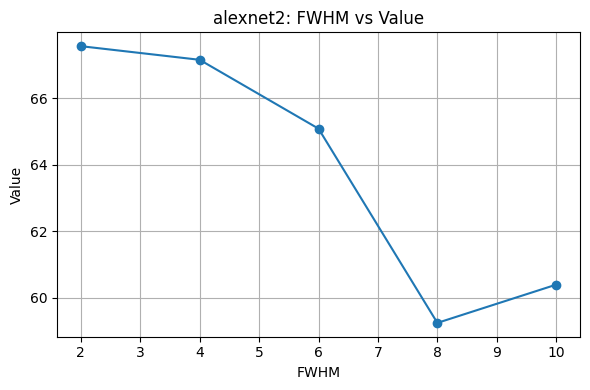

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


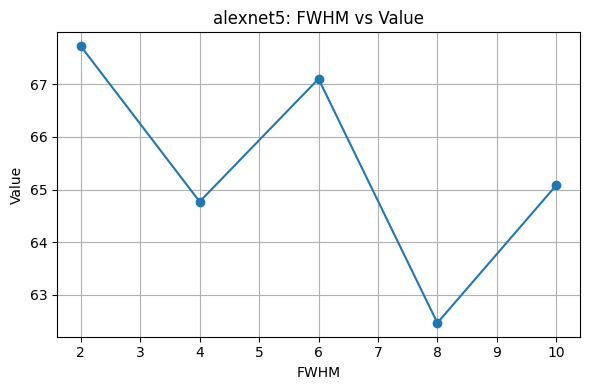

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


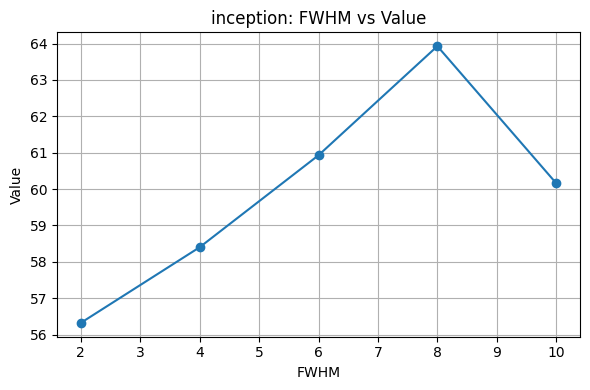

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


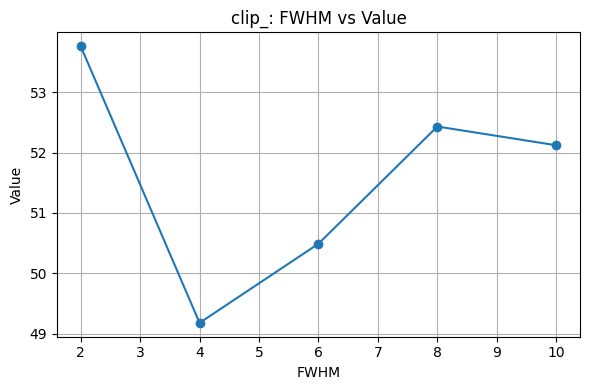

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


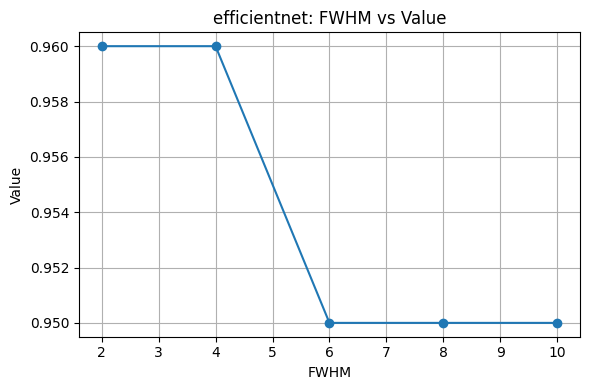

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


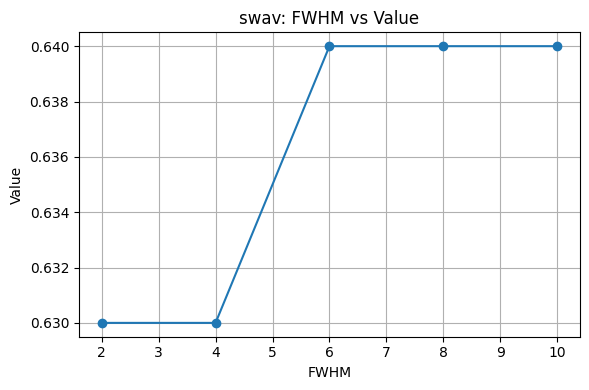

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


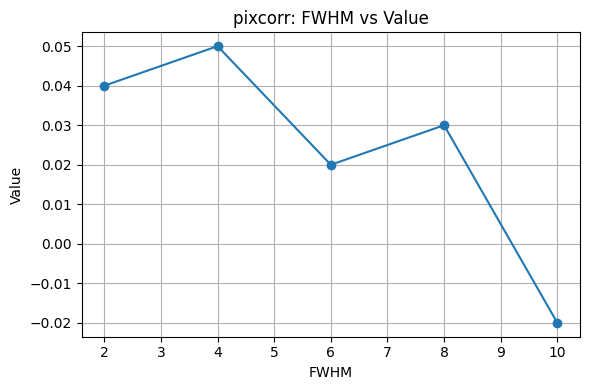

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


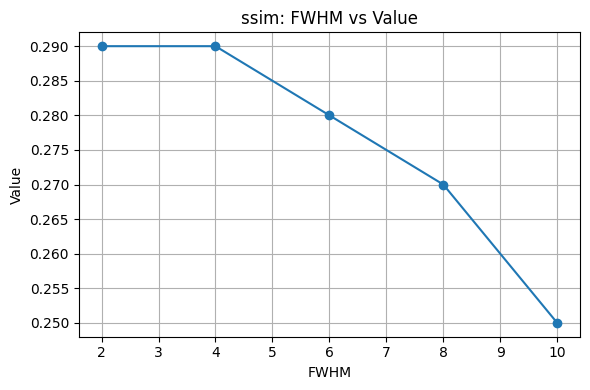

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


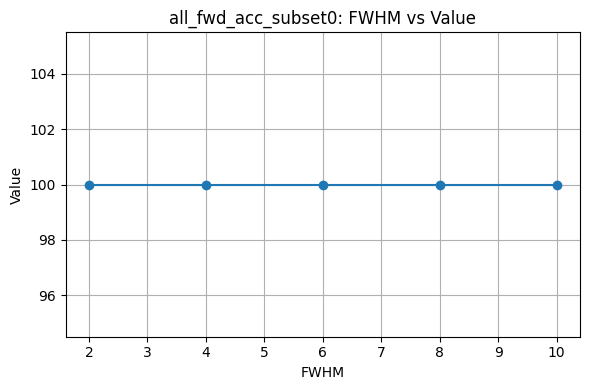

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


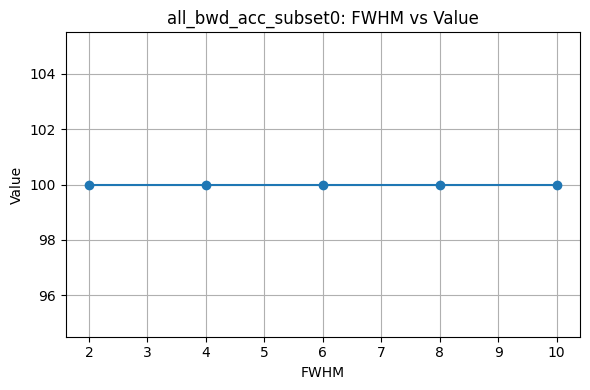

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


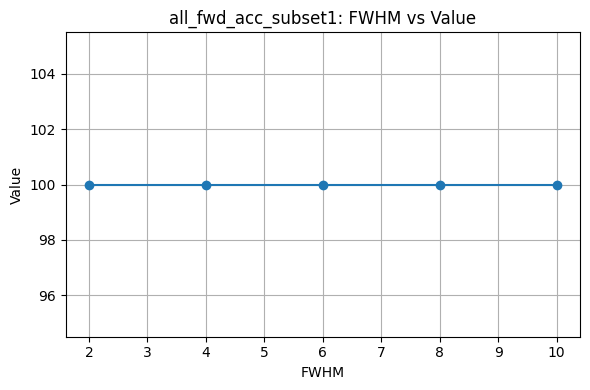

/tmp/ipykernel_22406/2649469313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['FWHM'] = subset['FWHM'].astype(float)


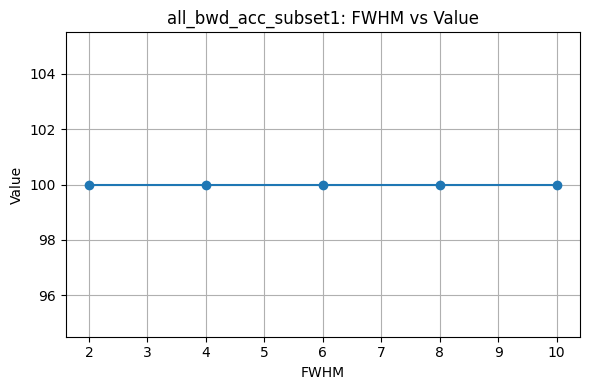

In [14]:
for metric in plot_df['Metric'].unique():
    subset = plot_df[plot_df['Metric']==metric]
    subset['FWHM'] = subset['FWHM'].astype(float)
    plt.figure(figsize=(6,4))
    plt.plot(subset['FWHM'], subset['Value'], marker='o')
    plt.xlabel('FWHM')
    plt.ylabel('Value')
    plt.title(f'{metric}: FWHM vs Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# # load and display all recons with originals
# all_recons_save = torch.load(os.path.join(save_path, "all_recons.pt"))
# for i in range(len(all_recons_save)):
#     plt.figure(figsize=(10, 5))
#     plt.subplot(1, 2, 1)
#     plt.title("Original Image")
#     plt.imshow(all_ground_truth_save[i].numpy().transpose(1, 2, 0), cmap='gray')
#     plt.axis('off')  # Hide axes
#     plt.subplot(1, 2, 2)
#     plt.title("Reconstructed Image")
#     plt.imshow(all_recons_save[i].numpy().transpose(1, 2, 0), cmap='gray')
#     plt.axis('off')  # Hide axes

#     plt.show()